Alex Weinstein and Andrea Keiper

DS4420

Boston Car Crashes Time Series Model

In [2]:
import pandas as pd

In [33]:
crashes = pd.read_csv("Boston_CrashDetails.csv", header=2)
crashes.head(5)

,Crash_Number,City_Town_Name,Crash_Date,Crash_Time,Crash_Severity,Maximum_Injury_Severity_Reported,Number_of_Vehicles,Total_Nonfatal_Injuries,Total_Fatal_Injuries,Manner_of_Collision,...,Ambient_Light,Weather_Condition,At_Roadway_Intersection,Distance_From_Nearest_Roadway_Intersection,Distance_From_Nearest_Milemarker,Distance_From_Nearest_Exit,Distance_From_Nearest_Landmark,Non_Motorist_Type,X_Cooordinate,Y_Cooordinate
0,2725539,BOSTON,01-Jan-2010,2:00 AM,Non-fatal injury,Non-fatal injury - Incapacitating,2,3,0,Rear-end,...,Daylight,"Sleet, hail (freezing rain or drizzle)",MORTON STREET / BLUE HILL AVENUE,MORTON STREET / BLUE HILL AVENUE,NaN,NaN,NaN,NaN,233688.296913,892724.750056
1,2576250,BOSTON,01-Jan-2010,2:02 AM,Not Reported,Not reported,2,0,0,Unknown,...,Dark - lighted roadway,Cloudy/Cloudy,BUNKER HILL STREET / ELM STREET,BUNKER HILL STREET / ELM STREET,NaN,NaN,NaN,NaN,236018.656211,903256.749810
2,2551708,BOSTON,01-Jan-2010,2:30 AM,Non-fatal injury,Non-fatal injury - Non-incapacitating,2,1,0,Angle,...,Dark - lighted roadway,Cloudy,NaN,COLUMBIA ROAD / BUTTONWOOD STREET,NaN,NaN,NaN,NaN,236609.587155,896844.662508
3,2560608,BOSTON,01-Jan-2010,2:32 AM,Property damage only (none injured),No injury,2,0,0,Rear-end,...,Dark - lighted roadway,Not Reported,MORTON STREET,MORTON STREET,NaN,NaN,NaN,NaN,NaN,NaN
4,2553095,BOSTON,01-Jan-2010,2:44 AM,Property damage only (none injured),No injury,1,0,0,Single vehicle crash,...,Dark - lighted roadway,Clear,NaN,Rte 90 W,Rte 90 W Milemarker 132.0,NaN,NaN,NaN,232572.239552,899870.482914


In [36]:
# One hot encoding crash severity so we can use it in our X matrix
crash_sev_dummies = pd.get_dummies(crashes['Crash_Severity'])
df_with_dummies = crashes.join(crash_sev_dummies)

df = df_with_dummies[['Crash_Date', 'Crash_Number', 'X_Cooordinate', 'Y_Cooordinate', 'Fatal injury', 'Non-fatal injury', 'Not Reported', 'Property damage only (none injured)', 'Unknown']].copy()

In [40]:
df['Crash_Date'] = pd.to_datetime(df['Crash_Date'])
df = df.set_index('Crash_Date')
df = df.sort_index()
df.head()

,Crash_Number,X_Cooordinate,Y_Cooordinate,Fatal injury,Non-fatal injury,Not Reported,Property damage only (none injured),Unknown
Crash_Date,,,,,,,,
2010-01-01,2725539,233688.296913,892724.750056,False,True,False,False,False
2010-01-01,2576250,236018.656211,903256.749810,False,False,True,False,False
2010-01-01,2551708,236609.587155,896844.662508,False,True,False,False,False
2010-01-01,2560608,NaN,NaN,False,False,False,True,False
2010-01-01,2553095,232572.239552,899870.482914,False,False,False,True,False


0
(194, 3)
            crash_count  year  month
Crash_Date                          
2010-01-31          433  2010      1
2010-02-28          299  2010      2
2010-03-31          354  2010      3
2010-04-30          345  2010      4
2010-05-31          465  2010      5
       crash_count         year       month
count   194.000000   194.000000  194.000000
mean    385.974227  2017.587629    6.448454
std      82.636067     4.677701    3.480504
min     143.000000  2010.000000    1.000000
25%     331.750000  2014.000000    3.000000
50%     370.000000  2018.000000    6.000000
75%     454.750000  2022.000000    9.000000
max     611.000000  2026.000000   12.000000


/var/folders/1c/g54gmhv53pg_h_y5p1flc0c80000gn/T/ipykernel_77149/4108361106.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df.resample('M').agg(


<Axes: title={'center': 'Daily Boston Crashes'}, xlabel='Crash_Date'>

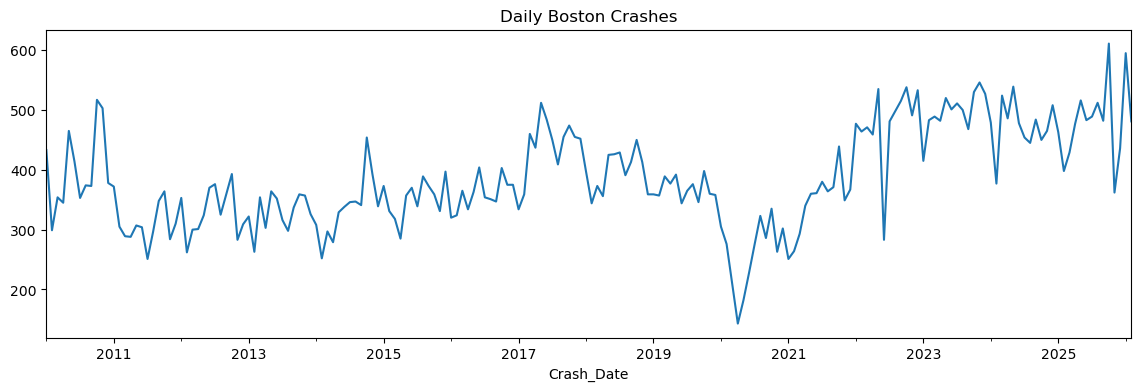

In [60]:
# Starting with number of crashes per month (day data was a lot and hard to follow)
ts = df.resample('M').agg(
    crash_count=('Crash_Number', 'count')
)

# Add time-based features
ts['year'] = ts.index.year
ts['month'] = ts.index.month

# I would use these two if I did a daily analysis
#ts['day_of_week'] = ts.index.dayofweek
#ts['is_weekend'] = ts['day_of_week'].isin([5, 6]).astype(int)


print((ts['crash_count']==0).sum()) # to show there are 0 months with no crash data
print(ts.shape)
print(ts.head())
print(ts.describe())
ts['crash_count'].plot(figsize=(14, 4), title='Daily Boston Crashes')

In [52]:
for i in range(1, 12):
    ts[f'Lag {i}'] = ts['crash_count'].shift(i)

ts = ts.dropna()
ts.head()

,crash_count,year,month,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11
Crash_Date,,,,,,,,,,,,,,
2010-12-31,378,2010,12,503.0,517.0,373.0,374.0,353.0,414.0,465.0,345.0,354.0,299.0,433.0
2011-01-31,372,2011,1,378.0,503.0,517.0,373.0,374.0,353.0,414.0,465.0,345.0,354.0,299.0
2011-02-28,305,2011,2,372.0,378.0,503.0,517.0,373.0,374.0,353.0,414.0,465.0,345.0,354.0
2011-03-31,289,2011,3,305.0,372.0,378.0,503.0,517.0,373.0,374.0,353.0,414.0,465.0,345.0
2011-04-30,288,2011,4,289.0,305.0,372.0,378.0,503.0,517.0,373.0,374.0,353.0,414.0,465.0


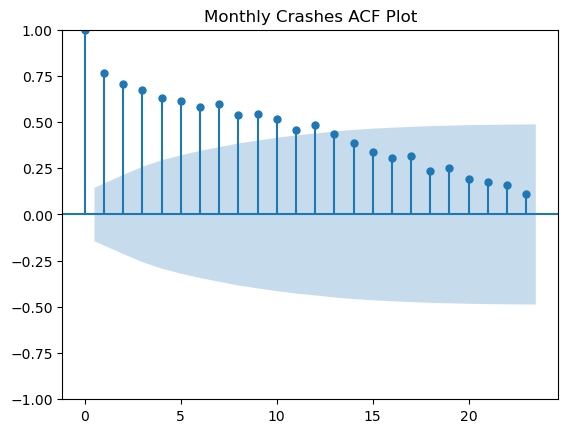

In [53]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF Plot
series = ts['crash_count']
plot_acf(series, title = 'Monthly Crashes ACF Plot')
plt.show()

Seeing geometric decay! That suggests an AR(p) model may be appropriate. Our literature suggested using integer-valued autoregressive (INAR) Poisson models, which we will investigate furhter

In [54]:
# THIS IS AN IDEA FOR LATER, USING SEVERITY SOMEHOW?
# The data needs to be at regular intervals for the time series analysis
# counts crashes per day and sums each severity type
severity_cols = ['Fatal injury', 'Non-fatal injury', 'Not Reported', 
                 'Property damage only (none injured)', 'Unknown']

ts2 = df.resample('D').agg(
    crash_count=('Crash_Number', 'count'),
    fatal=('Fatal injury', 'sum'),
    non_fatal=('Non-fatal injury', 'sum'),
    not_reported=('Not Reported', 'sum'),
    property_damage=('Property damage only (none injured)', 'sum'),
    unknown=('Unknown', 'sum')
)

# There are 0 days with 0 crashes in the dataset (yikes!), but this is good for time series
(ts2['crash_count'] == 0).sum()

0